In [1]:
from csv_reader import read_csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from aux import format_plot
from copy import deepcopy as copy

plt.rcParams['font.family'] = 'Helvetica'

BATCH_SIZE = 1
PARAMS_START = 2 + BATCH_SIZE
N_PAIRWISE_RULES_PER_TYPE = 12 * 2
N_SUMMED_WEIGHT_RULES_PER_TYPE = 6
N_THREE_FACTOR_RULES_PER_TYPE = 8
N_RULES = 3 * (N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE) + 2 * N_THREE_FACTOR_RULES_PER_TYPE
N_PAIRWISE_TIMECONSTS = 12
N_TIMECONSTS = N_PAIRWISE_TIMECONSTS + 32
tf_timeconst_start = N_RULES + N_PAIRWISE_TIMECONSTS
N_PARAMS = N_RULES + N_TIMECONSTS

R_RESCALING = 5
R_EXP_RESCALING = 5
W_RESCALING = 1
THREE_FACTOR_RESCALING = 2
SUMMED_WEIGHT_RESCALING = 0.01 # formerly 0.05

In [2]:
rule_names = [ # Define labels for all rules to be run during simulations
	r'',
	r'$y$',
	r'$x$',
	r'$y^2$',
	r'$x^2$',
	r'$y^3$',
	r'$x^3$',
	r'$y^4$',
	r'$x^4$',
	r'$x \, y$',
	r'$x \, \tilde{y}$',
	r'$\tilde{x} \, y$',

	r'$w$',
	r'$w y$',
	r'$w x$',
	r'$w y^2$',
	r'$w x^2$',
	r'$w y^3$',
	r'$w x^3$',
	r'$w y^4$',
	r'$w x^4$',
	r'$w x \, y$',
	r'$w x \, \tilde{y}$',
	r'$w \tilde{x} \, y$',

	r'$\sum_k w_{kj}$',
	r'$(\sum_k w_{kj})^2$',
	r'$(\sum_k w_{kj})^3$',
	r'$\sum_k w_{ik}$',
	r'$(\sum_k w_{ik})^2$',
	r'$(\sum_k w_{ik})^3$',
]

rule_names = [
	[r'$HD \rightarrow HD$ ' + r_name for r_name in rule_names],
	[r'$HD \rightarrow HR$ ' + r_name for r_name in rule_names],
	[r'$HR \rightarrow HD$ ' + r_name for r_name in rule_names],
]

rule_names_tripartite = [
	r'$\tilde{y}, z \sim y$',
	r'$\tilde{x}, z \sim y$',
	r'$x \tilde{y}, z \sim y$',
	r'$\tilde{x} y, z \sim y$',

	r'$w \tilde{y}, z \sim y$',
	r'$w \tilde{x}, z \sim y$',
	r'$w x \tilde{y}, z \sim y$',
	r'$w \tilde{x} y, z \sim y$',
]

rule_names += [
	[r'$HD \rightarrow HD, HR \sim HD$' + r_name for r_name in rule_names_tripartite],
	[r'$HR \rightarrow HD, HD \sim HD$' + r_name for r_name in rule_names_tripartite],
]


rule_names = [r for rs in rule_names for r in rs]
rule_names = np.array(rule_names, dtype=object)


In [3]:
for i, rn in enumerate(rule_names):
    print(i, rn)

0 $HD \rightarrow HD$ 
1 $HD \rightarrow HD$ $y$
2 $HD \rightarrow HD$ $x$
3 $HD \rightarrow HD$ $y^2$
4 $HD \rightarrow HD$ $x^2$
5 $HD \rightarrow HD$ $y^3$
6 $HD \rightarrow HD$ $x^3$
7 $HD \rightarrow HD$ $y^4$
8 $HD \rightarrow HD$ $x^4$
9 $HD \rightarrow HD$ $x \, y$
10 $HD \rightarrow HD$ $x \, \tilde{y}$
11 $HD \rightarrow HD$ $\tilde{x} \, y$
12 $HD \rightarrow HD$ $w$
13 $HD \rightarrow HD$ $w y$
14 $HD \rightarrow HD$ $w x$
15 $HD \rightarrow HD$ $w y^2$
16 $HD \rightarrow HD$ $w x^2$
17 $HD \rightarrow HD$ $w y^3$
18 $HD \rightarrow HD$ $w x^3$
19 $HD \rightarrow HD$ $w y^4$
20 $HD \rightarrow HD$ $w x^4$
21 $HD \rightarrow HD$ $w x \, y$
22 $HD \rightarrow HD$ $w x \, \tilde{y}$
23 $HD \rightarrow HD$ $w \tilde{x} \, y$
24 $HD \rightarrow HD$ $\sum_k w_{kj}$
25 $HD \rightarrow HD$ $(\sum_k w_{kj})^2$
26 $HD \rightarrow HD$ $(\sum_k w_{kj})^3$
27 $HD \rightarrow HD$ $\sum_k w_{ik}$
28 $HD \rightarrow HD$ $(\sum_k w_{ik})^2$
29 $HD \rightarrow HD$ $(\sum_k w_{ik})^3$
30 $HD 

In [4]:
DATA_PATH = './sims_out/260ms_jax_no_noise_2D_test_842587_2D_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-10-06_16:46:43.748457_run_None/train_data.csv'

o = read_csv(DATA_PATH, read_header=False)

In [5]:
coefs = np.array(o.iloc[0, PARAMS_START: PARAMS_START + N_PARAMS])

In [6]:
coefs

array([ 1.73797438e-02, -1.57037486e-04, -1.07232896e-02, -4.61037856e-04,
       -8.76355083e-03, -9.94300362e-03, -1.69553606e-03,  9.66376647e-03,
        8.54187557e-04, -6.74077220e-03, -1.41299616e-03, -2.68211556e-03,
       -2.46040445e-03,  5.35674844e-05,  3.37091323e-03,  3.25769337e-03,
        3.26442283e-03, -5.00377441e-04, -5.26223547e-03, -2.04859747e-03,
        1.02559054e-03,  1.87812808e-03, -1.09376883e-02,  8.58110083e-03,
        7.49750225e-03,  2.00307843e-03, -1.27469072e-02, -5.68145789e-03,
       -7.42749934e-03,  1.26658643e-02, -7.47164607e-03, -4.16887128e-03,
       -2.88735016e-03, -1.34544664e-02,  1.46766970e-02, -1.09506672e-02,
        4.70412171e-03, -7.97409740e-03,  5.20313416e-03,  1.82512432e-02,
       -9.01626088e-03,  9.66870394e-03, -6.94817006e-04,  6.49064553e-03,
       -9.65555701e-04, -2.39399400e-04,  2.07870200e-03,  2.19885281e-03,
        1.57095610e-03,  7.35108727e-03, -6.29050925e-03,  1.43770667e-03,
       -9.76796047e-03, -

In [7]:
def plot_heatmap(x1, x2, f, v=None, axs=None, fig=None):
    # Create meshgrid for broadcasting
    X1, X2 = np.meshgrid(x1, x2, indexing='ij')
    
    # Compute values
    w_ij_dot = f(X1, X2)
    
    cmap = sns.diverging_palette(250, 10, s=100, l=55, as_cmap=True)
    
    # Use TwoSlopeNorm to ensure white maps to 0
    v = np.abs(w_ij_dot).max() if v is None else v
    norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
    
    # Plot heatmap
    if axs is None: 
        fig, axs = plt.subplots(1, 1, figsize=(3, 3))
    im = axs.matshow(w_ij_dot, cmap=cmap, norm=norm)
    cbar = fig.colorbar(im)
    
    # axs.set_title('Heat map of presyn_f(a, w_ij)')
    
    format_plot(axs, axislabelsize=16, ticklabelsize=16)
    format_plot(cbar.ax)

    return fig, axs

# Function
def postsyn_f(a, w_ij, coefs, include_const=True):
    a *= R_RESCALING
    w_ij *= W_RESCALING
    return (
        coefs[0] * include_const
        + coefs[2] * a
        + coefs[4] * a**2
        + coefs[6] * a**3
        + coefs[8] * a**4
        + w_ij * (
            coefs[12] * include_const
            + coefs[14] * a
            + coefs[16] * a**2
            + coefs[18] * a**3
            + coefs[20] * a**4
        )
    )
    

def presyn_f(a, w_ij, coefs, include_const=True):
    a *= R_RESCALING
    w_ij *= W_RESCALING
    return (
        coefs[0] * include_const
        + coefs[1] * a
        + coefs[3] * a**2
        + coefs[5] * a**3
        + coefs[7] * a**4
        + w_ij * (
            coefs[12] * include_const
            + coefs[13] * a
            + coefs[15] * a**2
            + coefs[17] * a**3
            + coefs[19] * a**4
        )
    )
    

def pairwise_f(a1, a2, w_ij, t_lag, coefs):
    w_ij *= W_RESCALING
    return (
        coefs[9] * a1 * a2 * R_RESCALING**2 * np.isclose(t_lag, 0)
        + coefs[10] * a1 * a2 * R_RESCALING * R_EXP_RESCALING * np.where(t_lag > 0, np.exp(-t_lag / coefs[N_RULES + 0]), 0)
        + coefs[11] * a1 * a2 * R_RESCALING * R_EXP_RESCALING * np.where(t_lag < 0, np.exp(t_lag / coefs[N_RULES + 1]), 0)
        + w_ij * (
            coefs[21] * a1 * a2 * R_RESCALING**2 * np.isclose(t_lag, 0)
            + coefs[22] * a1 * a2 * R_RESCALING * R_EXP_RESCALING * np.where(t_lag > 0, np.exp(-t_lag / coefs[N_RULES + 2]), 0)
            + coefs[23] * a1 * a2 * R_RESCALING * R_EXP_RESCALING * np.where(t_lag < 0, np.exp(t_lag / coefs[N_RULES + 3]), 0)
        )
    )

def third_factor(tau, z, t_lag):
    return z * THREE_FACTOR_RESCALING * np.where(t_lag >= 0, np.exp(-t_lag / tau), 0)

def three_factor(a1, a2, z, w_ij, t_lag_1, t_lag_2, t_lag_z, coefs):
    w_ij *= W_RESCALING
    tf = third_factor(np.array([
        coefs[tf_timeconst_start + 1],
        coefs[tf_timeconst_start + 3],
        coefs[tf_timeconst_start + 5],
        coefs[tf_timeconst_start + 7],
        coefs[tf_timeconst_start + 9],
        coefs[tf_timeconst_start + 11],
        coefs[tf_timeconst_start + 13],
        coefs[tf_timeconst_start + 15],
    ]), z, t_lag_z)
    
    f = coefs[90] * a2 * R_EXP_RESCALING * np.where(t_lag_2 >= 0, np.exp(-t_lag_2 / coefs[tf_timeconst_start + 0]), 0) * tf[0] \
    + coefs[91] * a1 * R_EXP_RESCALING * np.where(t_lag_1 >= 0, np.exp(-t_lag_1 / coefs[tf_timeconst_start+ 2]), 0) * tf[1] \
    + coefs[92] * a1 * a2 * R_EXP_RESCALING * R_RESCALING * (np.abs(t_lag_1) < 0.1e-3) * np.where(tf_timeconst_start >= 0, np.exp(-t_lag_2 / coefs[tf_timeconst_start + 4]), 0) * tf[2] \
    + coefs[93] * a1 * a2 * R_EXP_RESCALING * R_RESCALING * np.where(t_lag_1 >= 0, np.exp(-t_lag_1 / coefs[tf_timeconst_start + 6]), 0) * (np.abs(t_lag_2) < 0.1e-3) *  tf[3] \
    + coefs[94] * w_ij * a2 * R_EXP_RESCALING * np.where(t_lag_2 >= 0, np.exp(-t_lag_2 / coefs[tf_timeconst_start + 8]), 0) * tf[4] \
    + coefs[95] * w_ij * a1 * R_EXP_RESCALING * np.where(t_lag_1 >= 0, np.exp(-t_lag_1 / coefs[tf_timeconst_start + 10]), 0) * tf[5] \
    + coefs[96] * w_ij * a1 * a2 * R_EXP_RESCALING * R_RESCALING * (np.abs(t_lag_1) < 0.1e-3) * np.where(t_lag_2 >= 0, np.exp(-t_lag_2 / coefs[tf_timeconst_start + 12]), 0) * tf[6] \
    + coefs[97] * w_ij * a1 * a2 * R_EXP_RESCALING * R_RESCALING * np.where(t_lag_1 >= 0, np.exp(-t_lag_1 / coefs[tf_timeconst_start + 14]), 0) * (np.abs(t_lag_2) < 0.1e-3) * tf[7]
    return f

def three_factor_z_post(a2, z, w_ij, t_lag, coefs):
    # t_lag here is the lag between z and t_pre, so t_pre - t_z
    # if lag is positive, use z's time const
    # if lag is negative, use t_pre's time const
    z *= THREE_FACTOR_RESCALING
    a2 *= R_EXP_RESCALING
    w_ij *= W_RESCALING
    
    f  = coefs[91] * a2 * z * np.where(t_lag >= 0, np.exp(-t_lag / coefs[tf_timeconst_start + 3]), np.exp(t_lag / coefs[tf_timeconst_start + 2])) \
        + coefs[95] * a2 * z * w_ij * np.where(t_lag >= 0, np.exp(-t_lag / coefs[tf_timeconst_start + 11]), np.exp(t_lag / coefs[tf_timeconst_start + 10]))
    return f

def three_factor_z_pre(a1, z, w_ij, t_lag, coefs):
    # t_lag here is the lag between z and t_post, so t_post - t_z
    # if lag is positive, use z's time const
    # if lag is negative, use t_post's time const
    z *= THREE_FACTOR_RESCALING
    a1 *= R_EXP_RESCALING
    w_ij *= W_RESCALING
    
    f  = coefs[90] * a1 * z * np.where(t_lag >= 0, np.exp(-t_lag / coefs[tf_timeconst_start + 1]), np.exp(t_lag / coefs[tf_timeconst_start + 0])) \
        + coefs[94] * a1 * z * w_ij * np.where(t_lag >= 0, np.exp(-t_lag / coefs[tf_timeconst_start + 9]), np.exp(t_lag / coefs[tf_timeconst_start + 8]))
    return f

def three_factor_pre_post_z(a1, a2, z, w_ij, t_lag_post_pre, t_lag_post_z, coefs):
    taus = [
        coefs[N_RULES + 5],
        coefs[N_RULES + 7],
        coefs[N_RULES + 13],
        coefs[N_RULES + 15],
    ]
    z *= THREE_FACTOR_RESCALING
    a1 *= R_EXP_RESCALING
    a2 *= R_RESCALING
    w_ij *= W_RESCALING
    tf = [third_factor(tau, z, t_lag_post_z) for tau in taus]

    f = coefs[92] * a1 * a2 * np.where(t_lag_post_pre >= 0, np.exp(-t_lag_post_pre / coefs[tf_timeconst_start + 4]), 0) * tf[0] \
        + coefs[93] * a1 * a2 * np.where(t_lag_post_pre < 0, np.exp(t_lag_post_pre / coefs[tf_timeconst_start + 6]), 0) * tf[1] \
        + coefs[96] * a1 * a2 * w_ij * np.where(t_lag_post_pre >= 0, np.exp(-t_lag_post_pre / coefs[tf_timeconst_start + 12]), 0) * tf[2] \
        + coefs[97] * a1 * a2 * w_ij * np.where(t_lag_post_pre < 0, np.exp(t_lag_post_pre / coefs[tf_timeconst_start + 14]), 0) * tf[3] \

    return f

def presyn_weight_bound(w1, w2, coefs):
    summed = (w1 + w2) * SUMMED_WEIGHT_RESCALING
    return (
        coefs[0]
        + w1 * coefs[12] * W_RESCALING
        + coefs[24] * summed
        + coefs[25] * summed**2
        + coefs[26] * summed**3
    )

def postsyn_weight_bound(w1, w2, coefs):
    summed = (w1 + w2) * SUMMED_WEIGHT_RESCALING
    return (
        coefs[0]
        + w1 * coefs[12] * W_RESCALING
        + coefs[27] * summed
        + coefs[28] * summed**2
        + coefs[29] * summed**3
    )

Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


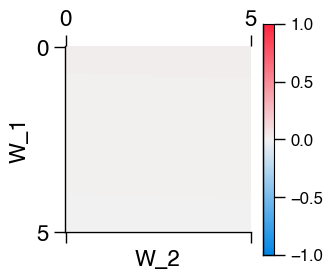

In [8]:
# Arrays
w_1 = np.linspace(0, 5, 100)
w_2 = np.linspace(0, 5, 100)

fig, axs = plot_heatmap(w_1, w_2, lambda w1, w2: presyn_weight_bound(w1, w2, coefs), v=1)
axs.set_ylabel('W_1')
axs.set_xlabel('W_2')

axs.set_xticks([0, 100], [0, 5])
axs.set_yticks([0, 100], [0, 5])

Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


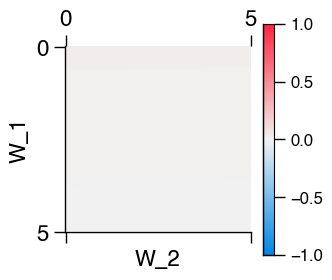

In [9]:
# Arrays
w_1 = np.linspace(0, 5, 100)
w_2 = np.linspace(0, 5, 100)

fig, axs = plot_heatmap(w_1, w_2, lambda w1, w2: postsyn_weight_bound(w1, w2, coefs), v=1)
axs.set_ylabel('W_1')
axs.set_xlabel('W_2')

axs.set_xticks([0, 100], [0, 5])
axs.set_yticks([0, 100], [0, 5])

In [10]:
coefs[24:30]

array([ 0.0074975 ,  0.00200308, -0.01274691, -0.00568146, -0.0074275 ,
        0.01266586])

Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


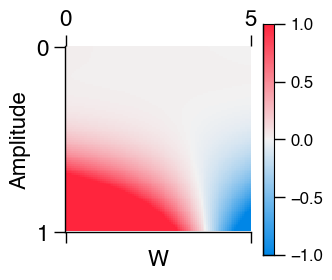

In [11]:
# Arrays
a = np.linspace(0, 1, 100)
w_ij = np.linspace(0, 5, 100)

fig, axs = plot_heatmap(a, w_ij, lambda a, w: presyn_f(a, w, coefs), v=1)
axs.set_ylabel('Amplitude')
axs.set_xlabel('W')

axs.set_xticks([0, 100], [0, 5])
axs.set_yticks([0, 100], [0, 1])

Axes(0.125,0.11;0.62x0.77)
Axes(0.78375,0.11;0.11625x0.77)


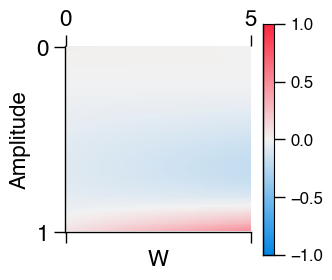

In [12]:
# Arrays
a = np.linspace(0, 1, 100)
w_ij = np.linspace(0, 5, 100)

fig, axs = plot_heatmap(a, w_ij, lambda a, w: postsyn_f(a, w, coefs), v=1)
axs.set_ylabel('Amplitude')
axs.set_xlabel('W')

axs.set_xticks([0, 100], [0, 5])
axs.set_yticks([0, 100], [0, 1])

In [13]:
def plot_pairwise(a_pre, a_post, coefs, axs, fig, set_label=True, v=None):
    w_ij = np.linspace(0, 10, 101)
    t_lag = np.linspace(-0.02, 0.02, 101)
    
    fig, axs = plot_heatmap(
        w_ij,
        t_lag, lambda w, t: pairwise_f(a_pre, a_post, w, t, coefs) \
            + postsyn_f(a_post, w, coefs, include_const=False) \
            + presyn_f(a_pre, w, coefs),
        v=v,
        axs=axs,
        fig=fig,
    )
    if set_label:
        axs.set_ylabel('W')
        axs.set_xlabel(r'$t_{\rm post} - t_{\rm pre} $')
    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 100], [0, 10])

In [14]:
def plot_pairwise_pre(w_ij, a_post, coefs, axs, fig, set_label=True, v=None):
    a_pre = np.linspace(0, 1, 100)
    t_lag = np.linspace(-0.02, 0.02, 100)
    
    fig, axs = plot_heatmap(
        a_pre,
        t_lag,
        lambda a_pre, t: pairwise_f(a_pre, a_post, w_ij, t, coefs) \
            + postsyn_f(a_post, w_ij, coefs, include_const=False) \
            + presyn_f(a_pre, w_ij, coefs),
        v=v,
        axs=axs,
        fig=fig,
    )
    if set_label:
        axs.set_ylabel(r'$a_{\rm pre}$')
        axs.set_xlabel(r'$t_{\rm post} - t_{\rm pre} $')
    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 100], [0, 1])

[[<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]]
Axes(0.125,0.653529;0.182353x0.226471)
Axes(0.31875,0.653529;0.0341912x0.226471)
Axes(0.398529,0.653529;0.182353x0.226471)
Axes(0.592279,0.653529;0.0341912x0.226471)
Axes(0.672059,0.653529;0.182353x0.226471)
Axes(0.865809,0.653529;0.0341912x0.226471)
Axes(0.125,0.381765;0.182353x0.226471)
Axes(0.31875,0.381765;0.0341912x0.226471)
Axes(0.398529,0.381765;0.182353x0.226471)
Axes(0.592279,0.381765;0.0341912x0.226471)
Axes(0.672059,0.381765;0.182353x0.226471)
Axes(0.865809,0.381765;0.0341912x0.226471)
Axes(0.125,0.11;0.182353x0.226471)
Axes(0.31875,0.11;0.0341912x0.226471)
Axes(0.398529,0.11;0.182353x0.226471)
Axes(0.592279,0.11;0.0341912x0.226471)
Axes(0.672059,0.11;0.182353x0.226471)
Axes(0.865809,0.11;0.0341912x0.226471)


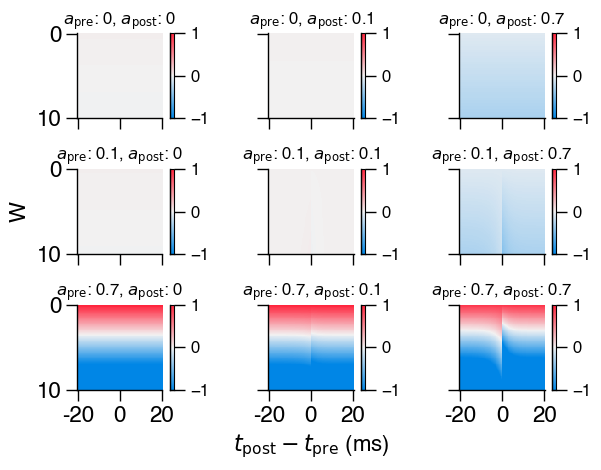

In [15]:
fig, axs = plt.subplots(3, 3, sharex=True, sharey=True)
print(axs)

conds = []
for a_pre in [0, 0.1, 0.7]:
    for a_post in [0, 0.1, 0.7]:
        conds.append((a_pre, a_post))

for i, (a_pre, a_post) in enumerate(conds):
    ax = axs[i // 3, i % 3]
    plot_pairwise(a_pre, a_post, coefs, ax, fig, set_label=False, v=1)
    # Only show x-ticks on bottom row
    if i // 3 != 2:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    ax.set_title(r'$a_{\rm pre}$: ' + f'{a_pre}, ' + r'$a_{\rm post}$: ' + f'{a_post}')
    # Only show y-ticks on first column

axs[1, 0].set_ylabel('W')
axs[-1, 1].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')
fig.tight_layout()

[[<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]]
Axes(0.125,0.653529;0.182353x0.226471)
Axes(0.31875,0.653529;0.0341912x0.226471)
Axes(0.398529,0.653529;0.182353x0.226471)
Axes(0.592279,0.653529;0.0341912x0.226471)
Axes(0.672059,0.653529;0.182353x0.226471)
Axes(0.865809,0.653529;0.0341912x0.226471)
Axes(0.125,0.381765;0.182353x0.226471)
Axes(0.31875,0.381765;0.0341912x0.226471)
Axes(0.398529,0.381765;0.182353x0.226471)
Axes(0.592279,0.381765;0.0341912x0.226471)
Axes(0.672059,0.381765;0.182353x0.226471)
Axes(0.865809,0.381765;0.0341912x0.226471)
Axes(0.125,0.11;0.182353x0.226471)
Axes(0.31875,0.11;0.0341912x0.226471)
Axes(0.398529,0.11;0.182353x0.226471)
Axes(0.592279,0.11;0.0341912x0.226471)
Axes(0.672059,0.11;0.182353x0.226471)
Axes(0.865809,0.11;0.0341912x0.226471)


Text(0.5, 0, '$t_{\\rm post} - t_{\\rm pre}$ (ms)')

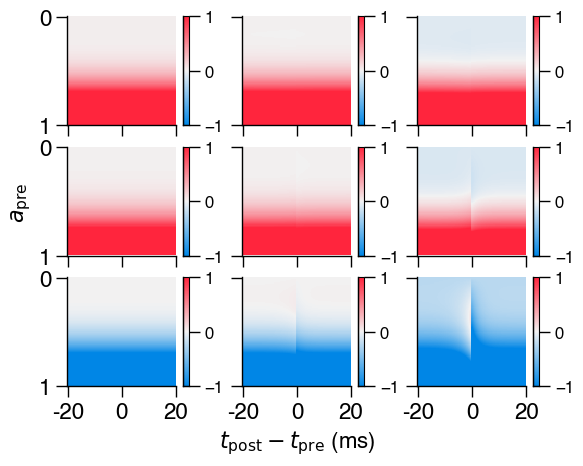

In [16]:
fig, axs = plt.subplots(3, 3, sharex=True, sharey=True)
print(axs)

conds = []
for w_ij in [0, 1, 7]:
    for a_post in [0, 0.1, 0.7]:
        conds.append((w_ij, a_post))

for i, (w_ij, a_post) in enumerate(conds):
    ax = axs[i // 3, i % 3]
    plot_pairwise_pre(w_ij, a_post, coefs, ax, fig, set_label=False, v=1)
    # Only show x-ticks on bottom row
    if i // 3 != 2:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    # Only show y-ticks on first column

axs[1, 0].set_ylabel(r'$a_{\rm pre}$')
axs[-1, 1].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')

In [17]:
def plot_triplet_pre(a_pre, z, coefs, axs, fig, set_label=True):
    w_ij = np.linspace(0, 10, 100)
    t_lag = np.linspace(-0.02, 0.02, 100)
    
    fig, axs = plot_heatmap(
        w_ij,
        t_lag,
        lambda w, t: three_factor_z_pre(a_pre, z, w, t, coefs),
        v=0.25,
        axs=axs,
        fig=fig,
    )
    if set_label:
        axs.set_ylabel('W')
        axs.set_xlabel(r'$t_{\rm pre} - t_{\rm z} $')
    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 100], [0, 10])

In [18]:
def plot_triplet_post(a_post, z, coefs, axs, fig, set_label=True):
    w_ij = np.linspace(0, 10, 100)
    t_lag = np.linspace(-0.02, 0.02, 100)
    
    fig, axs = plot_heatmap(
        w_ij,
        t_lag,
        lambda w, t: three_factor_z_post(a_post, z, w, t, coefs),
        v=0.25, 
        axs=axs,
        fig=fig,
    )
    if set_label:
        axs.set_ylabel('W')
        axs.set_xlabel(r'$t_{\rm post} - t_{\rm z} $')
    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 100], [0, 10])

In [19]:
def plot_triplet_pre_post(a_pre, a_post, z, w_ij, coefs, axs, fig, set_label=True):
    t_lag_post_z = np.linspace(0, 0.02, 100)
    t_lag_post_pre = np.linspace(-0.02, 0.02, 100)
    
    fig, axs = plot_heatmap(
        t_lag_post_z,
        t_lag_post_pre,
        lambda tl2, tl1: three_factor_pre_post_z(a_pre, a_post, z, w_ij, tl1, tl2, coefs),
        v=0.25,
        axs=axs,
        fig=fig,
    )
    if set_label:
        axs.set_ylabel(r'$t_{\rm post} - t_{\rm pre} $')
        axs.set_xlabel(r'$t_{\rm post} - t_{\rm z} $')
    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 100], [0, 20])

In [20]:
def plot_triplet_pre_post_w(a_pre, a_post, z, t_lag_post_z, coefs, axs, fig, set_label=True):
    w_ij = np.linspace(0, 10, 100)
    t_lag_post_pre = np.linspace(-0.02, 0.02, 100)
    
    fig, axs = plot_heatmap(
        w_ij,
        t_lag_post_pre,
        lambda w, tl1: three_factor_pre_post_z(a_pre, a_post, z, w, tl1, t_lag_post_z, coefs),
        v=0.25,
        axs=axs,
        fig=fig,
    )
    if set_label:
        axs.set_ylabel(r'$t_{\rm post} - t_{\rm pre} $')
        axs.set_xlabel(r'$t_{\rm post} - t_{\rm z} $')
    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 100], [0, 20])

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]
Axes(0.125,0.53;0.281818x0.35)
Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.547727,0.53;0.281818x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.125,0.11;0.281818x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.547727,0.11;0.281818x0.35)
Axes(0.847159,0.11;0.0528409x0.35)


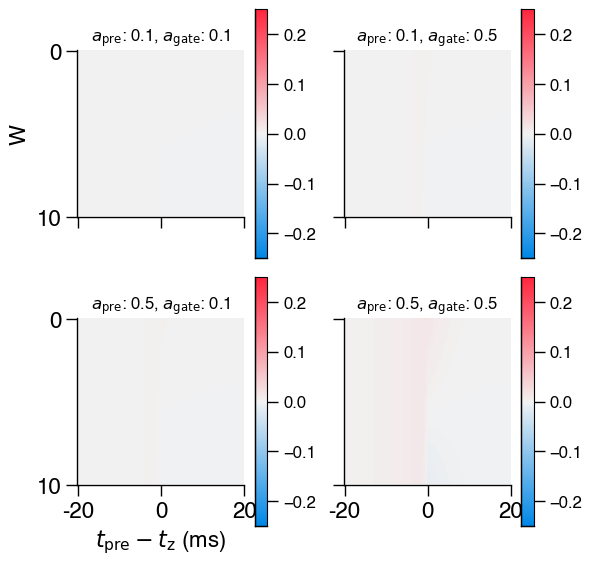

In [21]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(6, 6))
print(axs)

conds = []
for a_pre in [0.1, 0.5]:
    for z in [0.1, 0.5]:
        conds.append((a_pre, z))

for i, (a_pre, z) in enumerate(conds):
    ax = axs[i // 2, i % 2]
    plot_triplet_pre(a_pre, z, coefs, ax, fig, set_label=False)
    # Only show x-ticks on bottom row
    if i // 2 != 1:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    ax.set_title(r'$a_{\rm pre}$: ' + f'{a_pre}, ' + r'$a_{\rm gate}$: ' + f'{z}')
    # Only show y-ticks on first column

axs[0, 0].set_ylabel('W')
axs[1, 0].set_xlabel(r'$t_{\rm pre} - t_{\rm z}$ (ms)')
fig.tight_layout()

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]
Axes(0.125,0.53;0.281818x0.35)
Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.547727,0.53;0.281818x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.125,0.11;0.281818x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.547727,0.11;0.281818x0.35)
Axes(0.847159,0.11;0.0528409x0.35)


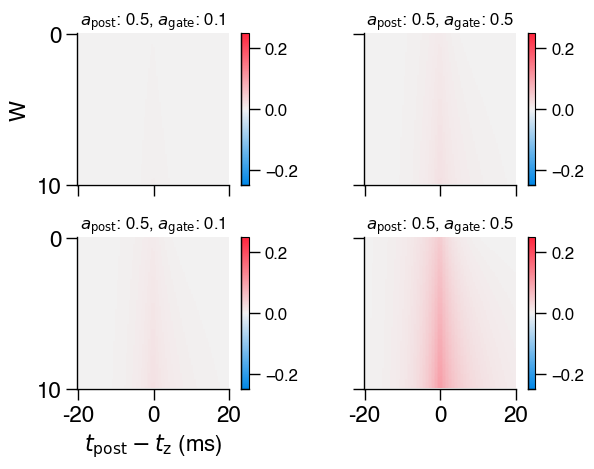

In [22]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
print(axs)

conds = []
for a_post in [0.1, 0.5]:
    for z in [0.1, 0.5]:
        conds.append((a_post, z))

for i, (a_post, z) in enumerate(conds):
    ax = axs[i // 2, i % 2]
    plot_triplet_post(a_post, z, coefs, ax, fig, set_label=False)
    # Only show x-ticks on bottom row
    if i // 2 != 1:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    ax.set_title(r'$a_{\rm post}$: ' + f'{a_pre}, ' + r'$a_{\rm gate}$: ' + f'{z}')
    # Only show y-ticks on first column

axs[0, 0].set_ylabel('W')
axs[1, 0].set_xlabel(r'$t_{\rm post} - t_{\rm z}$ (ms)')
fig.tight_layout()

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]
Axes(0.125,0.53;0.281818x0.35)
Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.547727,0.53;0.281818x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.125,0.11;0.281818x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.547727,0.11;0.281818x0.35)
Axes(0.847159,0.11;0.0528409x0.35)


Text(0.5, 0, '$t_{\\rm post} - t_{\\rm pre}$ (ms)')

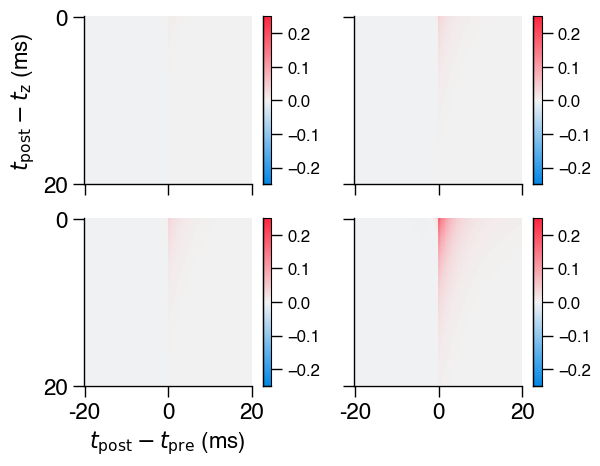

In [23]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
print(axs)

conds = []
for a_pre in [0.1, 0.5]:
    for a_post in [0.1, 0.5]:
        conds.append((a_pre, a_post))
z = 1
w_ij = 0.1

for i, (a_post, z) in enumerate(conds):
    ax = axs[i // 2, i % 2]
    plot_triplet_pre_post(a_pre, a_post, z, w_ij, coefs, ax, fig, set_label=False)
    # Only show x-ticks on bottom row
    if i // 2 != 1:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    # Only show y-ticks on first column

axs[0, 0].set_ylabel(r'$t_{\rm post} - t_{\rm z}$ (ms)')
axs[1, 0].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]
Axes(0.125,0.53;0.281818x0.35)
Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.547727,0.53;0.281818x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.125,0.11;0.281818x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.547727,0.11;0.281818x0.35)
Axes(0.847159,0.11;0.0528409x0.35)


Text(0.5, 0, '$t_{\\rm post} - t_{\\rm pre}$ (ms)')

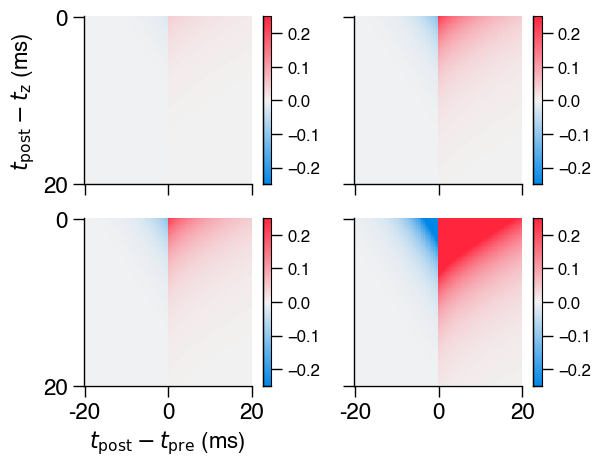

In [24]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
print(axs)

conds = []
for a_pre in [0.1, 0.5]:
    for a_post in [0.1, 0.5]:
        conds.append((a_pre, a_post))
z = 1
w_ij = 5

for i, (a_post, z) in enumerate(conds):
    ax = axs[i // 2, i % 2]
    plot_triplet_pre_post(a_pre, a_post, z, w_ij, coefs, ax, fig, set_label=False)
    # Only show x-ticks on bottom row
    if i // 2 != 1:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    # Only show y-ticks on first column

axs[0, 0].set_ylabel(r'$t_{\rm post} - t_{\rm z}$ (ms)')
axs[1, 0].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]
Axes(0.125,0.53;0.281818x0.35)
Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.547727,0.53;0.281818x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.125,0.11;0.281818x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.547727,0.11;0.281818x0.35)
Axes(0.847159,0.11;0.0528409x0.35)


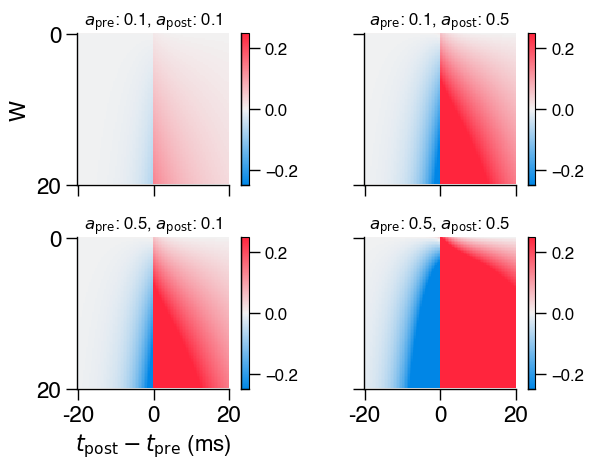

In [25]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
print(axs)

conds = []
for a_pre in [0.1, 0.5]:
    for a_post in [0.1, 0.5]:
        conds.append((a_pre, a_post))
z = 1
t_lag_post_z = 0.001

for i, (a_pre, a_post) in enumerate(conds):
    ax = axs[i // 2, i % 2]
    plot_triplet_pre_post_w(a_pre, a_post, z, t_lag_post_z, coefs, ax, fig, set_label=False)
    # Only show x-ticks on bottom row
    if i // 2 != 1:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    ax.set_title(r'$a_{\rm pre}$: ' + f'{a_pre}, ' + r'$a_{\rm post}$: ' + f'{a_post}')
    # Only show y-ticks on first column

axs[0, 0].set_ylabel('W')
axs[1, 0].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')
fig.tight_layout()

In [26]:
def plot_all(a_pre, a_post, z, t_lag_post_z, coefs, axs, fig, set_label=True, v=None):
    w_ij = np.linspace(0, 6, 101)
    t_lag = np.linspace(-0.02, 0.02, 101)
    
    fig, axs = plot_heatmap(
        w_ij,
        t_lag,
        lambda w, t: pairwise_f(a_pre, a_post, w, t, coefs) \
            + postsyn_f(a_post, w, coefs, include_const=False) \
            + presyn_f(a_pre, w, coefs) \
            + three_factor_z_pre(a_pre, z, w, t_lag_post_z - t, coefs) \
            + three_factor_z_post(a_post, z, w, t_lag_post_z, coefs) \
            + three_factor_pre_post_z(a_pre, a_post, z, w, t, t_lag_post_z, coefs),
        v=v,
        axs=axs,
        fig=fig,
    )
    if set_label:
        axs.set_ylabel('W')
        axs.set_xlabel(r'$t_{\rm post} - t_{\rm pre} $')
    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 100], [0, 6])

[[<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]]
Axes(0.125,0.653529;0.182353x0.226471)
Axes(0.31875,0.653529;0.0341912x0.226471)
Axes(0.398529,0.653529;0.182353x0.226471)
Axes(0.592279,0.653529;0.0341912x0.226471)
Axes(0.672059,0.653529;0.182353x0.226471)
Axes(0.865809,0.653529;0.0341912x0.226471)
Axes(0.125,0.381765;0.182353x0.226471)
Axes(0.31875,0.381765;0.0341912x0.226471)
Axes(0.398529,0.381765;0.182353x0.226471)
Axes(0.592279,0.381765;0.0341912x0.226471)
Axes(0.672059,0.381765;0.182353x0.226471)
Axes(0.865809,0.381765;0.0341912x0.226471)
Axes(0.125,0.11;0.182353x0.226471)
Axes(0.31875,0.11;0.0341912x0.226471)
Axes(0.398529,0.11;0.182353x0.226471)
Axes(0.592279,0.11;0.0341912x0.226471)
Axes(0.672059,0.11;0.182353x0.226471)
Axes(0.865809,0.11;0.0341912x0.226471)


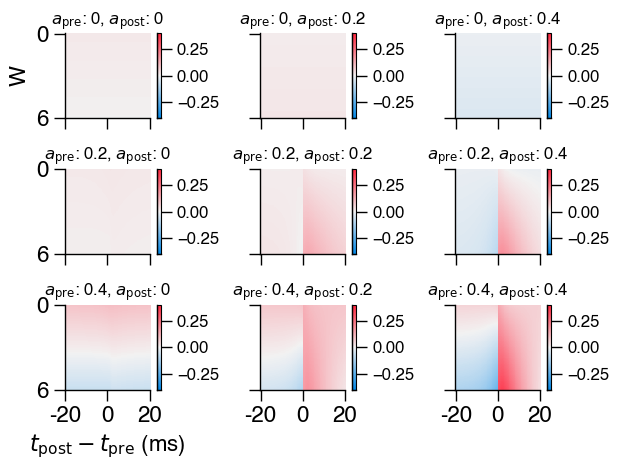

In [32]:
fig, axs = plt.subplots(3, 3, sharex=True, sharey=True)
print(axs)

conds = []
for a_pre in [0, 0.2, 0.4]:
    for a_post in [0, 0.2, 0.4]:
        conds.append((a_pre, a_post))
z = 0.5
t_lag_post_z = 0.001

for i, (a_pre, a_post) in enumerate(conds):
    ax = axs[i // 3, i % 3]
    plot_all(a_pre, a_post, z, t_lag_post_z, coefs, ax, fig, set_label=False, v=0.4)
    # Only show x-ticks on bottom row
    if i // 3 != 2:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    ax.set_title(r'$a_{\rm pre}$: ' + f'{a_pre}, ' + r'$a_{\rm post}$: ' + f'{a_post}')

axs[0, 0].set_ylabel('W')
axs[2, 0].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')
fig.tight_layout()
fig.savefig('./figures/250ms_no_het_learning_rule_plus_potentiation.svg')

[[<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]]
Axes(0.125,0.653529;0.182353x0.226471)
Axes(0.31875,0.653529;0.0341912x0.226471)
Axes(0.398529,0.653529;0.182353x0.226471)
Axes(0.592279,0.653529;0.0341912x0.226471)
Axes(0.672059,0.653529;0.182353x0.226471)
Axes(0.865809,0.653529;0.0341912x0.226471)
Axes(0.125,0.381765;0.182353x0.226471)
Axes(0.31875,0.381765;0.0341912x0.226471)
Axes(0.398529,0.381765;0.182353x0.226471)
Axes(0.592279,0.381765;0.0341912x0.226471)
Axes(0.672059,0.381765;0.182353x0.226471)
Axes(0.865809,0.381765;0.0341912x0.226471)
Axes(0.125,0.11;0.182353x0.226471)
Axes(0.31875,0.11;0.0341912x0.226471)
Axes(0.398529,0.11;0.182353x0.226471)
Axes(0.592279,0.11;0.0341912x0.226471)
Axes(0.672059,0.11;0.182353x0.226471)
Axes(0.865809,0.11;0.0341912x0.226471)


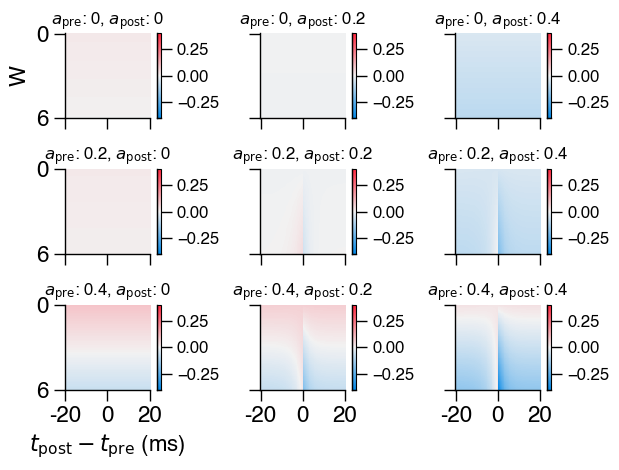

In [33]:
fig, axs = plt.subplots(3, 3, sharex=True, sharey=True)
print(axs)

conds = []
a_max = 0.4

for a_pre in [0, 0.2, 0.4]:
    for a_post in [0, 0.2, 0.4]:
        conds.append((a_pre, a_post))
z = 0
t_lag_post_z = 0.001

for i, (a_pre, a_post) in enumerate(conds):
    ax = axs[i // 3, i % 3]
    plot_all(a_pre, a_post, z, t_lag_post_z, coefs, ax, fig, set_label=False, v=0.4)
    # Only show x-ticks on bottom row
    if i // 3 != 2:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=False,
            top=False,
            labeltop=False,
        )
    else:
        ax.tick_params(
            axis='x',
            which='both',
            bottom=True,
            labelbottom=True,
            top=False,
            labeltop=False,
        )
    ax.set_title(r'$a_{\rm pre}$: ' + f'{a_pre}, ' + r'$a_{\rm post}$: ' + f'{a_post}')

axs[0, 0].set_ylabel('W')
axs[2, 0].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')
fig.tight_layout()
fig.savefig('./figures/250ms_no_het_learning_rule_no_potentiation.svg')